
#Email Spam Detection: BoW, TF-IDF та попередньо навчені ембедінги

Набір даних: Kaggle — `shantanudhakadd/email-spam-detection-dataset-classification`

> Датасет уже завантажено з Kaggle за допомогою API token та збережено локально у `data/spam.csv`. Повторна авторизація і повторне завантаження у фінальному notebook не потрібні.

#Імпорт 

In [2]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


#Шлях 

У проєкті вже є файл:

```text
data/spam.csv
```

Тому notebook одразу використовує локальний CSV. Код нижче працює незалежно від того, чи Jupyter запущено з кореня проєкту, чи з папки `notebooks`.

In [43]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_PATH = PROJECT_DIR / "data" / "spam.csv"

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset was not found at: {DATA_PATH}\n"
        "Make sure spam.csv is located inside the data folder."
    )

Project directory: c:\Users\PC\Desktop\email-spam-detection
Dataset path: c:\Users\PC\Desktop\email-spam-detection\data\spam.csv


#Завантаження датасету в Pandas

In [44]:
df_raw = pd.read_csv(
    DATA_PATH,
    encoding="latin-1"
)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully.
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


#Попередній аналіз даних (EDA)

In [45]:
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes)

print("\nMissing values:")
display(df_raw.isna().sum())

print("\nDuplicated rows:", df_raw.duplicated().sum())

display(df_raw.head())

Shape: (5572, 5)

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:


v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object


Missing values:


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


Duplicated rows: 403


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


#Автоматичне визначення текстової та цільової колонок

In [6]:
df = df_raw.copy()

text_candidates = ["text", "message", "email", "body", "content", "Message", "Text"]
target_candidates = ["label", "spam", "category", "class", "target", "Label", "Category"]

text_col = next((c for c in text_candidates if c in df.columns), None)
target_col = next((c for c in target_candidates if c in df.columns), None)

if text_col is None:
    object_cols = df.select_dtypes(include="object").columns.tolist()
    if object_cols:
        avg_lengths = {
            c: df[c].astype(str).str.len().mean()
            for c in object_cols
        }
        text_col = max(avg_lengths, key=avg_lengths.get)

if target_col is None:
    candidate_cols = [c for c in df.columns if c != text_col]
    low_cardinality = [c for c in candidate_cols if df[c].nunique(dropna=True) <= 10]
    if low_cardinality:
        target_col = low_cardinality[0]

print("Text column:", text_col)
print("Target column:", target_col)

if text_col is None or target_col is None:
    raise ValueError(
        f"Could not identify text/target columns. Columns: {df.columns.tolist()}"
    )

display(df[[text_col, target_col]].head())

Text column: v2
Target column: v1


,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [18]:
# Bag of Words (BoW)

bow_vectorizer = CountVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

print("BoW train shape:", X_train_bow.shape)
print("BoW validation shape:", X_val_bow.shape)

BoW train shape: (4126, 5456)
BoW validation shape: (1032, 5456)


#Розподіл цільової змінної

v1
ham     4516
spam     642
Name: count, dtype: int64

Proportions:
v1
ham     0.8755
spam    0.1245
Name: proportion, dtype: float64


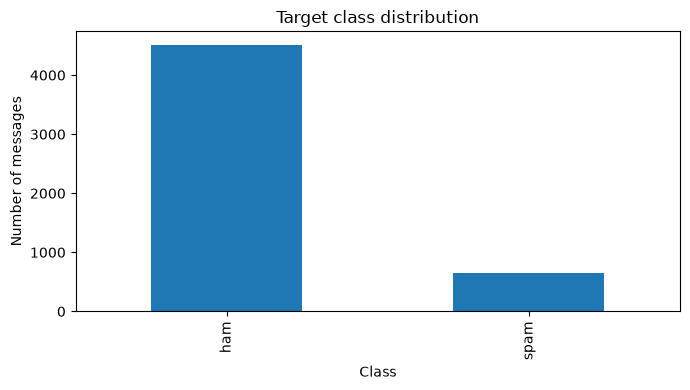

In [19]:
print(df[target_col].value_counts(dropna=False))
print("\nProportions:")
print(df[target_col].value_counts(normalize=True, dropna=False).round(4))

ax = df[target_col].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    title="Target class distribution"
)
ax.set_xlabel("Class")
ax.set_ylabel("Number of messages")
plt.tight_layout()
plt.show()

#Базове очищення таблиці

In [20]:
df = df[[text_col, target_col]].copy()

df = df.dropna(subset=[text_col, target_col])
df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col].str.len() > 0]

before = len(df)
df = df.drop_duplicates(subset=[text_col, target_col]).reset_index(drop=True)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal :", len(df))
display(df.head())

Rows before duplicate removal: 5158
Rows after duplicate removal : 5158


,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


#Кодування цільової змінної


ham = 0
spam = 1

In [21]:
target_series = df[target_col]

if pd.api.types.is_numeric_dtype(target_series):
    unique_values = sorted(pd.Series(target_series.dropna().unique()).tolist())

    if set(unique_values).issubset({0, 1}):
        df["target"] = target_series.astype(int)
    else:
        raise ValueError(f"Unexpected numeric target values: {unique_values}")
else:
    labels_normalized = target_series.astype(str).str.lower().str.strip()

    mapping = {
        "ham": 0,
        "spam": 1,
        "legitimate": 0,
        "legit": 0,
        "not spam": 0,
        "0": 0,
        "1": 1,
    }

    df["target"] = labels_normalized.map(mapping)

    if df["target"].isna().any():
        print("Unmapped labels:", labels_normalized[df["target"].isna()].unique())
        raise ValueError("Some labels could not be mapped to 0/1.")

print(df["target"].value_counts())
display(df[[text_col, target_col, "target"]].head())

target
0    4516
1     642
Name: count, dtype: int64


,v2,v1,target
0,"Go until jurong point, crazy.. Available only ...",ham,0
1,Ok lar... Joking wif u oni...,ham,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,1
3,U dun say so early hor... U c already then say...,ham,0
4,"Nah I don't think he goes to usf, he lives aro...",ham,0


#Попередня обробка тексту

In [22]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text: str) -> str:
    text = str(text).lower()

    # Зберігаємо інформацію про URL/email через спеціальні токени.
    text = re.sub(r"https?://\S+|www\.\S+", " url ", text)
    text = re.sub(r"\S+@\S+\.\S+", " email ", text)

    # Видаляємо спеціальні символи.
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Прибираємо зайві пробіли.
    text = re.sub(r"\s+", " ", text).strip()

    # Видаляємо stop words.
    tokens = [word for word in text.split() if word not in STOP_WORDS]

    return " ".join(tokens)

df["clean_text"] = df[text_col].apply(clean_text)

display(df[[text_col, "clean_text", "target"]].head(10))

,v2,clean_text,target
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,1
3,U dun say so early hor... U c already then say...,u dun say early hor u c say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives,0
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling s 3 week s word d like fun...,1
6,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent,0
7,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...,0
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...,1
9,Had your mobile 11 months or more? U R entitle...,mobile 11 months u r entitled update latest co...,1


#Розділення на training та validation

In [23]:
X = df["clean_text"]
y = df["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))

print("\nTrain proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation proportions:")
print(y_val.value_counts(normalize=True).round(4))

Training samples  : 4126
Validation samples: 1032

Train proportions:
target
0    0.8754
1    0.1246
Name: proportion, dtype: float64

Validation proportions:
target
0    0.876
1    0.124
Name: proportion, dtype: float64


#Bag of Words — CountVectorizer


In [24]:
bow_vectorizer = CountVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

print("BoW train shape:", X_train_bow.shape)
print("BoW val shape  :", X_val_bow.shape)

BoW train shape: (4126, 5456)
BoW val shape  : (1032, 5456)


#TF-IDF — TfidfVectorizer

In [25]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape  :", X_val_tfidf.shape)

TF-IDF train shape: (4126, 5456)
TF-IDF val shape  : (1032, 5456)


#Навчання моделей для BoW та TF-IDF


In [26]:
bow_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

tfidf_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

bow_model.fit(X_train_bow, y_train)
tfidf_model.fit(X_train_tfidf, y_train)

print("BoW and TF-IDF models trained successfully.")

BoW and TF-IDF models trained successfully.


#Попередньо навчені ембедінги — GloVe


In [27]:
import gensim.downloader as api

print("Loading pretrained GloVe embeddings...")
glove = api.load("glove-wiki-gigaword-50")

EMBEDDING_DIM = glove.vector_size
print("Embedding dimension:", EMBEDDING_DIM)

Loading pretrained GloVe embeddings...
[==================================================] 100.0% 66.0/66.0MB downloaded
Embedding dimension: 50


#Функція text → pretrained embedding vector

In [28]:
def text_to_embedding(text, embedding_model):
    tokens = str(text).split()

    vectors = [
        embedding_model[word]
        for word in tokens
        if word in embedding_model
    ]

    if not vectors:
        return np.zeros(embedding_model.vector_size, dtype=np.float32)

    return np.mean(vectors, axis=0)


def transform_texts_to_embeddings(texts, embedding_model):
    return np.vstack([
        text_to_embedding(text, embedding_model)
        for text in texts
    ])

X_train_emb = transform_texts_to_embeddings(X_train, glove)
X_val_emb = transform_texts_to_embeddings(X_val, glove)

print("Embedding train shape:", X_train_emb.shape)
print("Embedding val shape  :", X_val_emb.shape)

Embedding train shape: (4126, 50)
Embedding val shape  : (1032, 50)


#Модель класифікації для GloVe embeddings

In [29]:
embedding_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

embedding_model.fit(X_train_emb, y_train)

print("Embedding classifier trained successfully.")

Embedding classifier trained successfully.


#Оцінка моделей


In [30]:
def evaluate_model(name, model, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]

    accuracy = accuracy_score(y_valid, y_pred)
    auc = roc_auc_score(y_valid, y_proba)

    print(name)
    print("-" * len(name))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC : {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_valid, y_pred, target_names=["ham", "spam"]))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "ROC-AUC": auc,
        "Predictions": y_pred,
        "Probabilities": y_proba
    }

## 14. Оцінка BoW

In [31]:
bow_results = evaluate_model(
    "BoW + Logistic Regression",
    bow_model,
    X_val_bow,
    y_val
)

BoW + Logistic Regression
-------------------------
Accuracy: 0.9874
ROC-AUC : 0.9902

Classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       904
        spam       0.98      0.91      0.95       128

    accuracy                           0.99      1032
   macro avg       0.99      0.96      0.97      1032
weighted avg       0.99      0.99      0.99      1032



#Оцінка TF-IDF

In [32]:
tfidf_results = evaluate_model(
    "TF-IDF + Logistic Regression",
    tfidf_model,
    X_val_tfidf,
    y_val
)

TF-IDF + Logistic Regression
----------------------------
Accuracy: 0.9816
ROC-AUC : 0.9919

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       904
        spam       0.92      0.93      0.93       128

    accuracy                           0.98      1032
   macro avg       0.96      0.96      0.96      1032
weighted avg       0.98      0.98      0.98      1032



#Оцінка GloVe embeddings

In [33]:
embedding_results = evaluate_model(
    "GloVe + Logistic Regression",
    embedding_model,
    X_val_emb,
    y_val
)

GloVe + Logistic Regression
---------------------------
Accuracy: 0.8837
ROC-AUC : 0.9528

Classification report:
              precision    recall  f1-score   support

         ham       0.98      0.88      0.93       904
        spam       0.52      0.90      0.66       128

    accuracy                           0.88      1032
   macro avg       0.75      0.89      0.79      1032
weighted avg       0.93      0.88      0.90      1032



#Порівняння моделей

In [34]:
results_df = pd.DataFrame([
    {
        "Model": bow_results["Model"],
        "Accuracy": bow_results["Accuracy"],
        "ROC-AUC": bow_results["ROC-AUC"]
    },
    {
        "Model": tfidf_results["Model"],
        "Accuracy": tfidf_results["Accuracy"],
        "ROC-AUC": tfidf_results["ROC-AUC"]
    },
    {
        "Model": embedding_results["Model"],
        "Accuracy": embedding_results["Accuracy"],
        "ROC-AUC": embedding_results["ROC-AUC"]
    }
]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,ROC-AUC
0,TF-IDF + Logistic Regression,0.981589,0.991885
1,BoW + Logistic Regression,0.987403,0.990234
2,GloVe + Logistic Regression,0.883721,0.952805


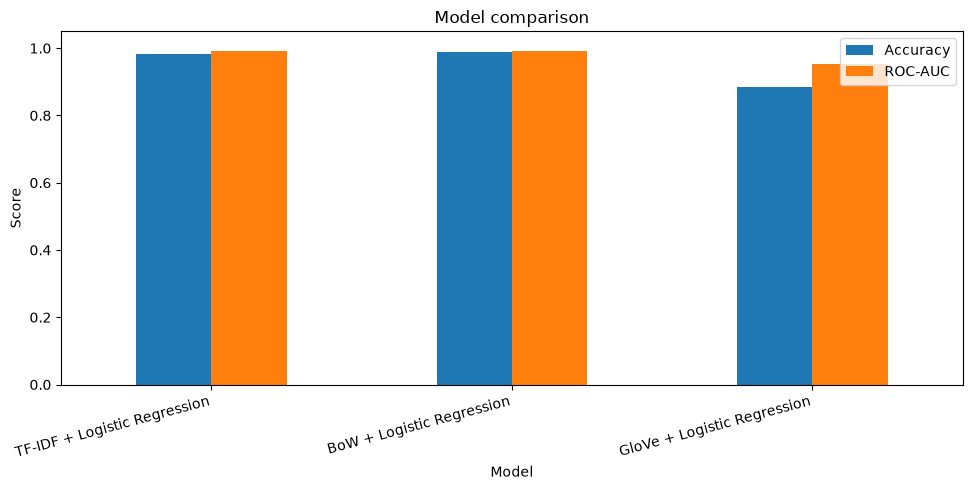

In [35]:
ax = results_df.set_index("Model")[["Accuracy", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1.05),
    title="Model comparison"
)

ax.set_ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

#Confusion matrices

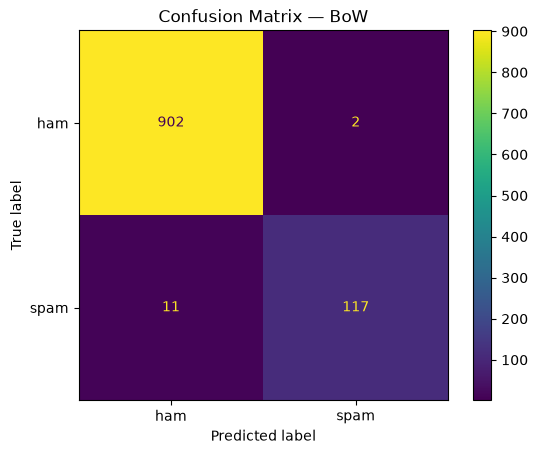

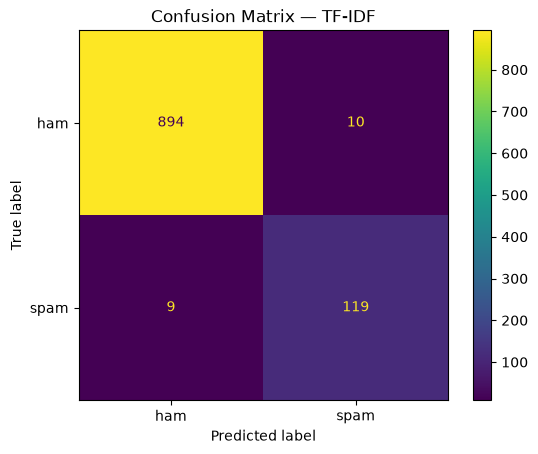

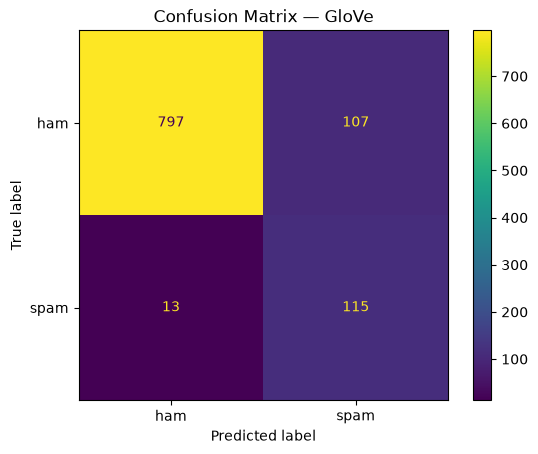

In [36]:
models_for_cm = [
    ("BoW", bow_results["Predictions"]),
    ("TF-IDF", tfidf_results["Predictions"]),
    ("GloVe", embedding_results["Predictions"])
]

for name, preds in models_for_cm:
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["ham", "spam"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

#ROC curves

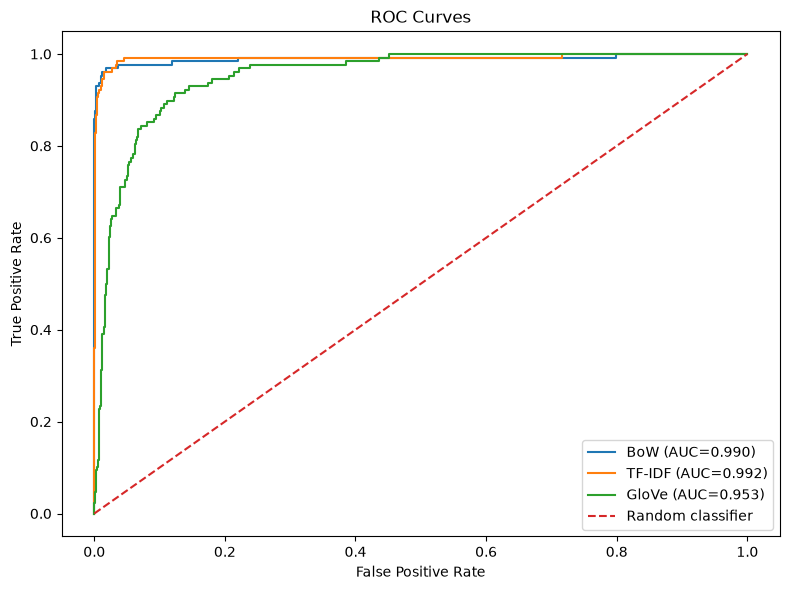

In [37]:
probability_sets = [
    ("BoW", bow_results["Probabilities"]),
    ("TF-IDF", tfidf_results["Probabilities"]),
    ("GloVe", embedding_results["Probabilities"])
]

plt.figure(figsize=(8, 6))

for name, probabilities in probability_sets:
    fpr, tpr, _ = roc_curve(y_val, probabilities)
    auc = roc_auc_score(y_val, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

#Інтерпретація TF-IDF моделі

In [38]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = tfidf_model.coef_[0]

top_spam_idx = np.argsort(coefficients)[-20:][::-1]
top_ham_idx = np.argsort(coefficients)[:20]

top_spam_features = pd.DataFrame({
    "feature": feature_names[top_spam_idx],
    "coefficient": coefficients[top_spam_idx]
})

top_ham_features = pd.DataFrame({
    "feature": feature_names[top_ham_idx],
    "coefficient": coefficients[top_ham_idx]
})

print("Features most associated with SPAM:")
display(top_spam_features)

print("Features most associated with HAM:")
display(top_ham_features)

Features most associated with SPAM:


,feature,coefficient
0,url,4.935171
1,txt,4.360995
2,mobile,4.103317
3,claim,3.711264
4,free,3.476899
5,50,3.381196
6,150p,3.361187
7,text,3.311821
8,reply,3.297632
9,service,3.009730


Features most associated with HAM:


,feature,coefficient
0,ok,-2.137734
1,ll,-1.715408
2,da,-1.666826
3,got,-1.661452
4,home,-1.633076
5,come,-1.598978
6,lt,-1.596849
7,gt,-1.576002
8,sorry,-1.564154
9,think,-1.524229


#Аналіз помилок найкращої моделі

In [39]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model by ROC-AUC:", best_model_name)

result_map = {
    bow_results["Model"]: bow_results,
    tfidf_results["Model"]: tfidf_results,
    embedding_results["Model"]: embedding_results,
}

best_results = result_map[best_model_name]

error_analysis = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "true_label": y_val.reset_index(drop=True),
    "predicted_label": best_results["Predictions"],
    "spam_probability": best_results["Probabilities"]
})

errors = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
].copy()

print("Number of validation errors:", len(errors))
display(errors.head(20))

Best model by ROC-AUC: TF-IDF + Logistic Regression
Number of validation errors: 19


,text,true_label,predicted_label,spam_probability
18,ok ur typical reply,0,1,0.565284
87,msg rajini comes,0,1,0.550662
197,send new number,0,1,0.736435
205,sorry missed let s talk time m 07090201529,1,0,0.088476
254,nokia phone lovly,0,1,0.529243
299,lookatme thanks purchase video clip lookatme v...,1,0,0.342286
389,babe u want dont u baby im nasty thing 4 filth...,1,0,0.366932
391,bank granite issues strong buy explosive pick ...,1,0,0.465665
408,did u receive msg,0,1,0.532562
799,m yahoo messenger just send message ll send mo...,0,1,0.639823


#Підсумкові метрики

In [40]:
best_row = results_df.iloc[0]

print(
    f"Найкраща модель за ROC-AUC: {best_row['Model']} | "
    f"Accuracy={best_row['Accuracy']:.4f} | "
    f"ROC-AUC={best_row['ROC-AUC']:.4f}"
)

display(results_df)

Найкраща модель за ROC-AUC: TF-IDF + Logistic Regression | Accuracy=0.9816 | ROC-AUC=0.9919


,Model,Accuracy,ROC-AUC
0,TF-IDF + Logistic Regression,0.981589,0.991885
1,BoW + Logistic Regression,0.987403,0.990234
2,GloVe + Logistic Regression,0.883721,0.952805


Висновок

Було порівняно три підходи до представлення текстових даних: Bag of Words, TF-IDF та попередньо навчені GloVe embeddings. Для класифікації в усіх трьох випадках було використано Logistic Regression.

Найвище значення ROC-AUC = 0.9919 показала модель TF-IDF + Logistic Regression, при цьому її Accuracy становить 0.9816. Модель BoW + Logistic Regression отримала дещо нижчий ROC-AUC (0.9902), але найвищу Accuracy — 0.9874. Різниця між двома моделями невелика, і обидва count-based підходи продемонстрували дуже високу якість.

Модель на основі GloVe embeddings показала нижчі результати: Accuracy = 0.8837, ROC-AUC = 0.9528. Однією з причин може бути використання усередненого вектора слів для всього повідомлення, через що втрачається порядок слів та послаблюється вплив характерних для спаму лексичних ознак.

Оскільки датасет є незбалансованим, ROC-AUC є важливішою метрикою для загального порівняння моделей, ніж Accuracy сама по собі. Тому за основною обраною метрикою найкращою моделлю визначено TF-IDF + Logistic Regression.

Аналіз коефіцієнтів TF-IDF моделі також показав логічні ознаки спаму: url, txt, mobile, claim, free, prize, sms, win, urgent. Це підтверджує, що TF-IDF добре виділяє характерні лексичні патерни спам-повідомлень.

#Перевірка власного повідомлення

In [42]:
def predict_email_tfidf(email_text):
    cleaned = clean_text(email_text)
    vector = tfidf_vectorizer.transform([cleaned])

    pred = tfidf_model.predict(vector)[0]
    probability = tfidf_model.predict_proba(vector)[0, 1]

    return {
        "prediction": "SPAM" if pred == 1 else "HAM",
        "spam_probability": float(probability)
    }

example_email = (
    "Congratulations! You have won a free prize. "
    "Click the link now to claim your reward."
)

predict_email_tfidf(example_email)

{'prediction': 'SPAM', 'spam_probability': 0.9576751459636512}